In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from dataset import *
from rmap import *
from second_selection import *
from sklearn.metrics import average_precision_score, roc_auc_score
# from itertools import product
# from collections import Counter, OrderedDict
# from rdkit import Chem
# from rdkit.Chem import Draw
# import os

In [2]:
target_cores = [0,1,3,7,8]
aggregations = ["All median", "All average", "Maximum"]

nonzero_dicts = []
allmedian_dicts = []
allaverage_dicts = []
maximum_dicts = []
for t in target_cores :
    nonzero_dicts.append(joblib.load(f"../saved_results/suzuki/{t}/rmap_cv_6_rmap_cv.joblib"))
    allmedian_dicts.append(joblib.load(f"../saved_results/suzuki/{t}/rmap_cv_6_rmap_cv_includeZero_median.joblib"))
    allaverage_dicts.append(joblib.load(f"../saved_results/suzuki/{t}/rmap_cv_6_rmap_cv_includeZero_average.joblib"))
    maximum_dicts.append(joblib.load(f"../saved_results/suzuki/{t}/rmap_cv_6_rmap_cv_includeZero_maximum.joblib"))

## Whether pilot BBs overlap when dataset is represented with different aggregation schemes

In [3]:
# Looking at the selected pilot BBs
pilotBB_dict = {
    "Target core":[],
    "Comparing aggregation":[],
    "Number of overlapping BBs":[]
}
for i, (nonzero_dict, allmedian_dict, allaverage_dict, maximum_dict) in enumerate(zip(
    nonzero_dicts, allmedian_dicts, allaverage_dicts, maximum_dicts
)):
    # Check that the randomly left out 14 BBs are all the same
    for nz_test, am_test, aa_test, m_test in zip(
        nonzero_dict["test_bb_inds"], allmedian_dict["test_bb_inds"], allaverage_dict["test_bb_inds"], maximum_dict["test_bb_inds"]
    ):
        assert np.all(nz_test == am_test)
        assert np.all(nz_test == aa_test)
        assert np.all(nz_test == m_test)

    # Inspecting the pilot BBs
    for nz_remain, am_remain, aa_remain, m_remain, train_bb_inds in zip(
        nonzero_dict["remaining_inds"], allmedian_dict["remaining_inds"], allaverage_dict["remaining_inds"], maximum_dict["remaining_inds"],
        nonzero_dict["train_bb_inds"]
    ):
        nz_pilot = [train_bb_inds[x] for x in range(55) if x not in nz_remain]
        am_pilot = [train_bb_inds[x] for x in range(55) if x not in am_remain]
        aa_pilot = [train_bb_inds[x] for x in range(55) if x not in aa_remain]
        m_pilot = [train_bb_inds[x] for x in range(55) if x not in m_remain]

        pilotBB_dict["Target core"].extend([target_cores[i]] * 3)
        pilotBB_dict["Comparing aggregation"].extend(aggregations)
        pilotBB_dict["Number of overlapping BBs"].extend([
            len(np.intersect1d(nz_pilot, am_pilot)),
            len(np.intersect1d(nz_pilot, aa_pilot)),
            len(np.intersect1d(nz_pilot, m_pilot))
        ])

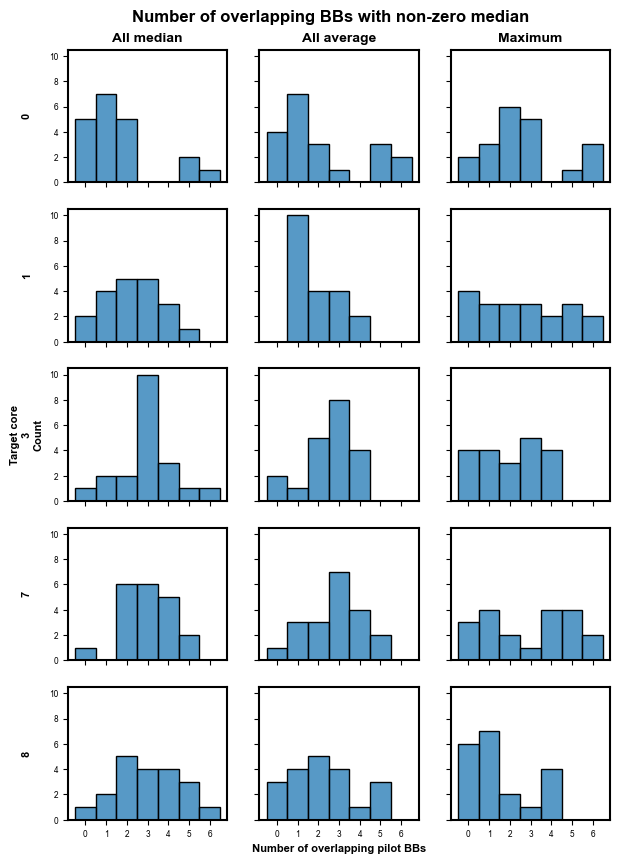

In [ ]:
fig, ax = plt.subplots(figsize=(7, 10), sharey=True, sharex=True, ncols=3, nrows=5)

hist_df = pd.DataFrame(pilotBB_dict)

fig.suptitle("Number of overlapping BBs with non-zero median", 
            # fontdict={"family":"arial", "size":10},
            fontweight="bold",
            fontsize=12,
            fontfamily="arial",
            y=0.92)
for i, agg in enumerate(aggregations) :
    for j, target_core in enumerate(target_cores):
        sns.histplot(
            data=hist_df[
                (hist_df["Comparing aggregation"]==agg)\
                      & (hist_df["Target core"]==target_core)
            ],
            x="Number of overlapping BBs",
            bins=np.arange(0, 7),
            discrete=True,
            ax=ax[j, i]
        )
        ax[j,i].set_yticks(np.arange(0, 11, 2))
        ax[j,i].set_xticks(np.arange(0, 7, 1))
        if i == 0 :
            ax[j,i].set_yticklabels(np.arange(0, 11, 2), fontdict={"family":"arial", "size":6})
            if j == 2 :
                ax[j,i].set_ylabel(f"Target core\n{target_core}\nCount", fontdict={"family":"arial", "size":8, "weight":"bold"})
            else :
                ax[j,i].set_ylabel(f"\n{target_core}\n", fontdict={"family":"arial", "size":8, "weight":"bold"})
        if j == 4 :
            ax[j,i].set_xticklabels(np.arange(0, 7, 1), fontdict={"family":"arial", "size":6})
            if i == 1 :
                ax[j,i].set_xlabel("Number of overlapping pilot BBs", fontdict={"family":"arial", "size":8, "weight":"bold"})
            else :
                ax[j,i].set_xlabel("")
        elif j == 0 :
            ax[j,i].set_title(agg, fontdict={"family":"arial", "size":10, "weight":"bold"})
        
        for axis in ["top", "bottom", "left", "right"]:
            ax[j, i].spines[axis].set_linewidth(1.5)

# plt.savefig("../figures/SI/FigureS38.svg", format="svg", dpi=300)

## Comparing predictivity

In [5]:
# Comparing the predictivity of LP on remaining

score_dict = {
    "Target core":[],
    "Comparing aggregation":[],
    "Comparing AUPRC":[],
    "Non-zero median AUPRC":[],
    "Comparing ROC-AUC":[],
    "Non-zero median ROC-AUC":[]
}
for i, (nonzero_dict, allmedian_dict, allaverage_dict, maximum_dict) in enumerate(zip(
    nonzero_dicts, allmedian_dicts, allaverage_dicts, maximum_dicts
)):
    # Inspecting the pilot BBs
    for nz_remain, am_remain, aa_remain, m_remain,\
         nz_target, am_target, aa_target, m_target,\
             nz_proba, am_proba, aa_proba, m_proba,\
                  train_bb_inds in zip(
        nonzero_dict["remaining_inds"], allmedian_dict["remaining_inds"], allaverage_dict["remaining_inds"], maximum_dict["remaining_inds"],
        nonzero_dict["target"], allmedian_dict["target"], allaverage_dict["target"], maximum_dict["target"],
        nonzero_dict["proba"], allmedian_dict["proba"], allaverage_dict["proba"], maximum_dict["proba"],
        nonzero_dict["train_bb_inds"]
    ):
        for agg, one_remain, one_target, one_proba in zip(
            aggregations, [am_remain, aa_remain, m_remain], [am_target, aa_target, m_target], [am_proba, aa_proba, m_proba]
        ):
            inds_to_compare = []
            for overlap_remaining_ind in  np.intersect1d(nz_remain, one_remain):
                if nz_target[nz_remain.index(overlap_remaining_ind)] == one_target[one_remain.index(overlap_remaining_ind)]:
                    inds_to_compare.append(overlap_remaining_ind)

            comparing_auprc = average_precision_score(
                [one_target[one_remain.index(x)] for x in inds_to_compare],
                [one_proba[one_remain.index(x)] for x in inds_to_compare]
            )
            comparing_rocauc = roc_auc_score(
                [one_target[one_remain.index(x)] for x in inds_to_compare],
                [one_proba[one_remain.index(x)] for x in inds_to_compare]
            )
            nonzero_auprc = average_precision_score(
                [nz_target[nz_remain.index(x)] for x in inds_to_compare],
                [nz_proba[nz_remain.index(x)] for x in inds_to_compare]
            )
            nonzero_rocauc = roc_auc_score(
                [nz_target[nz_remain.index(x)] for x in inds_to_compare],
                [nz_proba[nz_remain.index(x)] for x in inds_to_compare]
            )

            score_dict["Target core"].append(target_cores[i])
            score_dict["Comparing aggregation"].append(agg)
            score_dict["Comparing AUPRC"].append(comparing_auprc)
            score_dict["Comparing ROC-AUC"].append(comparing_rocauc)
            score_dict["Non-zero median AUPRC"].append(nonzero_auprc)
            score_dict["Non-zero median ROC-AUC"].append(nonzero_rocauc)

All median // target core 1
[-0.24, -0.124, -0.086, -0.039, -0.025, -0.004, 0.003, 0.009, 0.011, 0.012, 0.019, 0.025, 0.05, 0.094, 0.094, 0.155, 0.281, 0.313, 0.38, 0.382]

All median // target core 2
[-0.102, -0.096, -0.093, -0.088, -0.087, -0.087, -0.076, -0.056, -0.052, -0.043, -0.043, -0.042, -0.035, -0.02, 0.008, 0.02, 0.045, 0.045, 0.069, 0.131]

All median // target core 4
[-0.295, -0.233, -0.024, -0.016, -0.015, -0.01, -0.007, -0.003, -0.002, 0.006, 0.008, 0.014, 0.017, 0.049, 0.052, 0.06, 0.069, 0.069, 0.071, 0.262]

All median // target core 8
[-0.179, -0.166, -0.109, -0.014, -0.003, 0.008, 0.012, 0.046, 0.05, 0.073, 0.082, 0.13, 0.156, 0.194, 0.208, 0.236, 0.247, 0.27, 0.344, 0.538]

All median // target core 9
[-0.401, -0.148, -0.027, -0.006, 0.019, 0.021, 0.022, 0.03, 0.03, 0.032, 0.034, 0.043, 0.044, 0.097, 0.124, 0.133, 0.149, 0.18, 0.185, 0.219]

All average // target core 1
[-0.266, -0.169, -0.137, -0.124, -0.091, -0.076, -0.006, -0.004, -0.002, 0.003, 0.006, 0.011, 0.

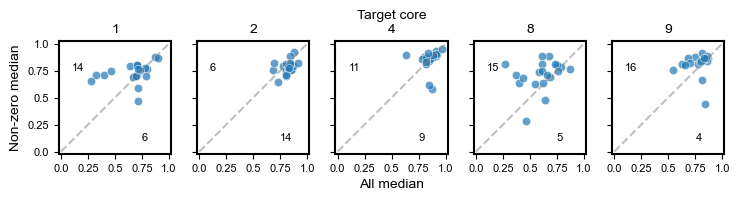

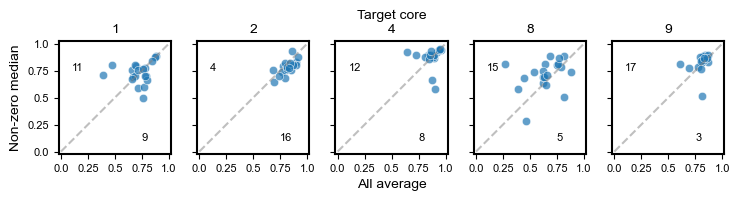

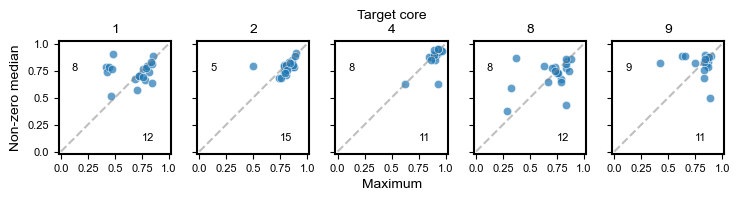

In [69]:
median_scores = [np.zeros((2, 5)), np.zeros((2, 5)), np.zeros((2, 5))]
for a in range(3):
    df_to_plot = pd.DataFrame(score_dict)
    fig, ax = plt.subplots(figsize=(7.5, 2), ncols=5, tight_layout=True, sharey=True)
    for i, t in enumerate(target_cores):
        sub_df = df_to_plot[(df_to_plot["Target core"]==t) & (df_to_plot["Comparing aggregation"]==aggregations[a])]
        score_diffs = sub_df["Non-zero median AUPRC"].values - sub_df["Comparing AUPRC"].values
        ax[i].annotate(len(np.where(score_diffs > 0)[0]), (0.1, 0.75), font="arial", fontsize=8)
        ax[i].annotate(len(np.where(score_diffs < 0)[0]), (0.75, 0.1), font="arial", fontsize=8)
        print(aggregations[a], "// target core", t+1)
        print([round(x, 3) for x in np.sort(score_diffs)])
        median_scores[a][0, i] = round(sub_df["Non-zero median AUPRC"].median(), 3)
        median_scores[a][1, i] = round(sub_df["Comparing AUPRC"].median(), 3)
        print()
        sns.scatterplot(data=sub_df, x="Comparing AUPRC", y="Non-zero median AUPRC", ax=ax[i], alpha=0.7)
        ax[i].set_aspect("equal")
        for axis in ["top", "bottom", "left", "right"]:
            ax[i].spines[axis].set_linewidth(1.5)
        ax[i].set_xlim(-0.02, 1.02)
        ax[i].set_ylim(-0.02, 1.02)
        ax[i].set_xticks(np.arange(0, 1.1, 0.25))
        ax[i].set_xticklabels([f"{round(x,2):02}" for x in np.arange(0, 1.1, 0.25)], fontsize=8,fontfamily="Arial")
        ax[i].set_yticks(np.arange(0, 1.1, 0.25))
        if i == 0 :
            ax[i].set_yticklabels([f"{round(x,2):02}" for x in np.arange(0, 1.1, 0.25)], fontsize=8,fontfamily="Arial")
            ax[i].set_ylabel("Non-zero median", fontdict={"fontsize": 10, "fontfamily": "Arial"})
        if i == 2 :
            ax[i].set_xlabel(aggregations[a], fontdict={"fontsize": 10, "fontfamily": "Arial"})
            ax[i].set_title(f"Target core\n{t+1}", fontdict={"fontsize": 10, "fontfamily": "Arial"})
        else :
            ax[i].set_title(f"{t+1}", fontdict={"fontsize": 10, "fontfamily": "Arial"})
            ax[i].set_xlabel("")

        ax[i].plot(np.arange(0, 1.01, 0.02), np.arange(0, 1.01, 0.02),ls="--", color="grey", alpha=0.5)

In [70]:
median_scores

[array([[0.73 , 0.785, 0.873, 0.741, 0.845],
        [0.708, 0.827, 0.85 , 0.618, 0.811]]),
 array([[0.734, 0.785, 0.897, 0.737, 0.845],
        [0.737, 0.812, 0.87 , 0.647, 0.815]]),
 array([[0.752, 0.786, 0.897, 0.746, 0.855],
        [0.743, 0.809, 0.898, 0.755, 0.856]])]

## Comparing LP against baseline with different aggregation schemes

In [3]:
baseline_nonzero_dicts = []
baseline_allmedian_dicts = []
baseline_allaverage_dicts = []
baseline_maximum_dicts = []
for t in target_cores :
    baseline_nonzero_dicts.append(joblib.load(f"../saved_results/suzuki/{t}/rmap_cv_6_baseline.joblib"))
    baseline_allmedian_dicts.append(joblib.load(f"../saved_results/suzuki/{t}/rmap_cv_6_baseline_includeZero_median.joblib"))
    baseline_allaverage_dicts.append(joblib.load(f"../saved_results/suzuki/{t}/rmap_cv_6_baseline_includeZero_average.joblib"))
    baseline_maximum_dicts.append(joblib.load(f"../saved_results/suzuki/{t}/rmap_cv_6_baseline_includeZero_maximum.joblib"))

### Comparing difficult 29 BBs

In [6]:
aggregations = ["Non-zero median", "All median", "All average", "Maximum"]
agg_entry = ["_", "median", "average", "maximum"]

vs_baseline_dict = {
    "Target core":[],
    "Aggregation":[],
    "LP AUPRC":[],
    "Baseline AUPRC":[],
    "Baseline ROC-AUC":[],
    "LP ROC-AUC":[]
}
for a, (lp_dicts, baseline_dicts) in enumerate(zip(
    [nonzero_dicts, allmedian_dicts, allaverage_dicts, maximum_dicts],
    [baseline_nonzero_dicts, baseline_allmedian_dicts, baseline_allaverage_dicts, baseline_maximum_dicts]
)):
    for i, (lp_dict, baseline_dict) in enumerate(zip(lp_dicts, baseline_dicts)):
        for lp_remaining_inds, baseline_remaining_inds,\
              lp_target, baseline_target,\
                  lp_proba, baseline_proba, test_bb_inds in zip(lp_dict["remaining_inds"], baseline_dict["remaining_inds"], lp_dict["target"], baseline_dict["target"], lp_dict["proba"], baseline_dict["proba"], lp_dict["test_bb_inds"]):
            assert np.all(lp_remaining_inds == baseline_remaining_inds)
            # Focusing on the intermediate 29 BBs
            if a == 0 :
                rmap = ReactivityMap(
                    source_core_inds=None,
                    target_core_ind=target_cores[i],
                    test_bb_inds=test_bb_inds,
                    dataset=SuzukiDataset(from_notebook=True, aggregation="median", exclude_zero_from_median=True)
                )
            else :
                rmap = ReactivityMap(
                    source_core_inds=None,
                    target_core_ind=target_cores[i],
                    test_bb_inds=test_bb_inds,
                    dataset=SuzukiDataset(from_notebook=True, aggregation=agg_entry[a], exclude_zero_from_median=False)
                )
            source_yield_sum = np.argsort(
                np.sum(rmap.source_yield_array, axis=0)[lp_remaining_inds]
            )
            inds_to_consider = [x for x in source_yield_sum[10:-10]] # index within remaining_inds

            baseline_auprc = average_precision_score(
                baseline_target[inds_to_consider],
                baseline_proba[inds_to_consider]
            )
            lp_auprc = average_precision_score(
                lp_target[inds_to_consider],
                lp_proba[inds_to_consider]
            )
            baseline_rocauc = roc_auc_score(
                baseline_target[inds_to_consider],
                baseline_proba[inds_to_consider]
            )
            lp_rocauc = roc_auc_score(
                lp_target[inds_to_consider],
                lp_proba[inds_to_consider]
            )
            vs_baseline_dict["Target core"].append(target_cores[i])
            vs_baseline_dict["Aggregation"].append(aggregations[a])
            vs_baseline_dict["LP AUPRC"].append(lp_auprc)
            vs_baseline_dict["LP ROC-AUC"].append(lp_rocauc)
            vs_baseline_dict["Baseline AUPRC"].append(baseline_auprc)
            vs_baseline_dict["Baseline ROC-AUC"].append(baseline_rocauc)

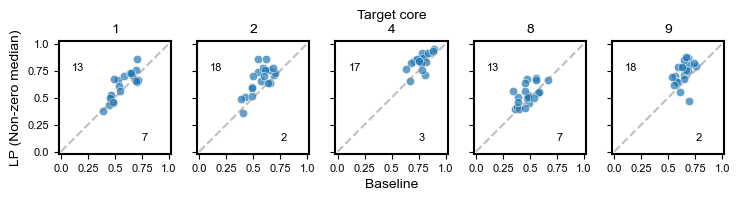

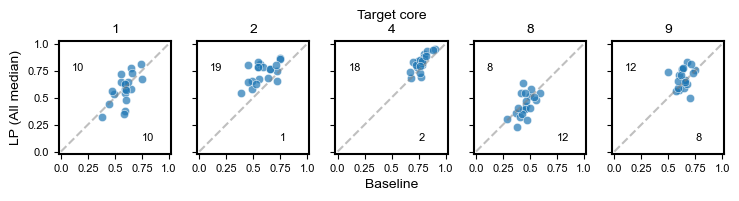

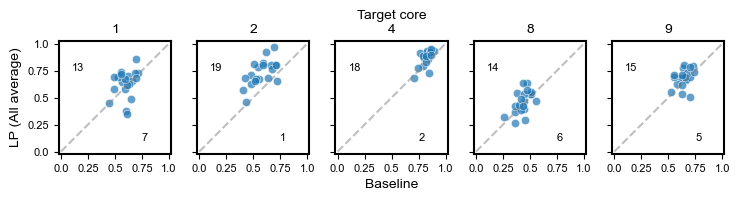

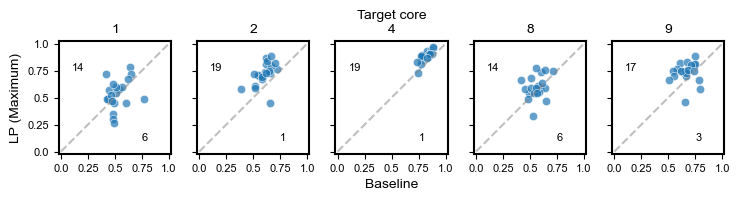

In [8]:
# median_scores = [np.zeros((2, 5)), np.zeros((2, 5)), np.zeros((2, 5))]
score_diff_list = [np.zeros((20,5)), np.zeros((20,5)), np.zeros((20,5)), np.zeros((20,5))] 

for a in range(4):
    df_to_plot = pd.DataFrame(vs_baseline_dict)
    fig, ax = plt.subplots(figsize=(7.5, 2), ncols=5, tight_layout=True, sharey=True)
    for i, t in enumerate(target_cores):
        sub_df = df_to_plot[(df_to_plot["Target core"]==t) & (df_to_plot["Aggregation"]==aggregations[a])]
        score_diffs = sub_df["LP AUPRC"].values - sub_df["Baseline AUPRC"].values
        score_diff_list[a][:, i] = score_diffs
        ax[i].annotate(len(np.where(score_diffs > 0)[0]), (0.1, 0.75), font="arial", fontsize=8)
        ax[i].annotate(len(np.where(score_diffs < 0)[0]), (0.75, 0.1), font="arial", fontsize=8)
        print()
        sns.scatterplot(data=sub_df, x="Baseline AUPRC", y="LP AUPRC", ax=ax[i], alpha=0.7)
        ax[i].set_aspect("equal")
        for axis in ["top", "bottom", "left", "right"]:
            ax[i].spines[axis].set_linewidth(1.5)
        ax[i].set_xlim(-0.02, 1.02)
        ax[i].set_ylim(-0.02, 1.02)
        ax[i].set_xticks(np.arange(0, 1.1, 0.25))
        ax[i].set_xticklabels([f"{round(x,2):02}" for x in np.arange(0, 1.1, 0.25)], fontsize=8,fontfamily="Arial")
        ax[i].set_yticks(np.arange(0, 1.1, 0.25))
        if i == 0 :
            ax[i].set_yticklabels([f"{round(x,2):02}" for x in np.arange(0, 1.1, 0.25)], fontsize=8,fontfamily="Arial")
            ax[i].set_ylabel(f"LP ({aggregations[a]})", fontdict={"fontsize": 10, "fontfamily": "Arial"})
        if i == 2 :
            ax[i].set_xlabel("Baseline", fontdict={"fontsize": 10, "fontfamily": "Arial"})
            ax[i].set_title(f"Target core\n{t+1}", fontdict={"fontsize": 10, "fontfamily": "Arial"})
        else :
            ax[i].set_title(f"{t+1}", fontdict={"fontsize": 10, "fontfamily": "Arial"})
            ax[i].set_xlabel("")

        ax[i].plot(np.arange(0, 1.01, 0.02), np.arange(0, 1.01, 0.02),ls="--", color="grey", alpha=0.5)
    # plt.savefig(f"../figures/SI/FigureSX_{aggregations[a]}.svg", format="svg", dpi=300)

In [9]:
per_core_auprc_benefit = [np.mean(x, axis=0) for x in score_diff_list]
all_auprc_benefit = [np.mean(x) for x in per_core_auprc_benefit]

In [10]:
per_core_auprc_benefit

[array([0.04253867, 0.10311813, 0.06560653, 0.05356684, 0.0895506 ]),
 array([-0.00696099,  0.14637379,  0.05222778, -0.01778041,  0.04101614]),
 array([0.02806825, 0.1603176 , 0.05094179, 0.03102065, 0.03929282]),
 array([0.00863143, 0.12272477, 0.06900643, 0.03807805, 0.07025751])]

In [11]:
all_auprc_benefit

[0.07087615228093598,
 0.04297526119401898,
 0.06192822092424201,
 0.06173963926572088]

### All 49 BBs

In [12]:
all_vs_baseline_dict = {
    "Target core":[],
    "Aggregation":[],
    "LP AUPRC":[],
    "Baseline AUPRC":[],
    "Baseline ROC-AUC":[],
    "LP ROC-AUC":[]
}
for a, (lp_dicts, baseline_dicts) in enumerate(zip(
    [nonzero_dicts, allmedian_dicts, allaverage_dicts, maximum_dicts],
    [baseline_nonzero_dicts, baseline_allmedian_dicts, baseline_allaverage_dicts, baseline_maximum_dicts]
)):
    for i, (lp_dict, baseline_dict) in enumerate(zip(lp_dicts, baseline_dicts)):
        for lp_remaining_inds, baseline_remaining_inds,\
              lp_target, baseline_target,\
                  lp_proba, baseline_proba, test_bb_inds in zip(lp_dict["remaining_inds"], baseline_dict["remaining_inds"], lp_dict["target"], baseline_dict["target"], lp_dict["proba"], baseline_dict["proba"], lp_dict["test_bb_inds"]):
            assert np.all(lp_remaining_inds == baseline_remaining_inds)
            # Focusing on the intermediate 29 BBs
            baseline_auprc = average_precision_score(
                baseline_target,
                baseline_proba
            )
            lp_auprc = average_precision_score(
                lp_target,
                lp_proba
            )
            baseline_rocauc = roc_auc_score(
                baseline_target,
                baseline_proba
            )
            lp_rocauc = roc_auc_score(
                lp_target,
                lp_proba
            )
            all_vs_baseline_dict["Target core"].append(target_cores[i])
            all_vs_baseline_dict["Aggregation"].append(aggregations[a])
            all_vs_baseline_dict["LP AUPRC"].append(lp_auprc)
            all_vs_baseline_dict["LP ROC-AUC"].append(lp_rocauc)
            all_vs_baseline_dict["Baseline AUPRC"].append(baseline_auprc)
            all_vs_baseline_dict["Baseline ROC-AUC"].append(baseline_rocauc)

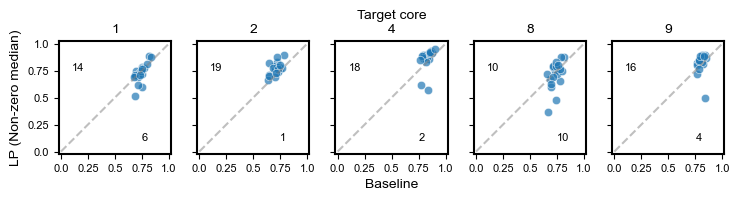

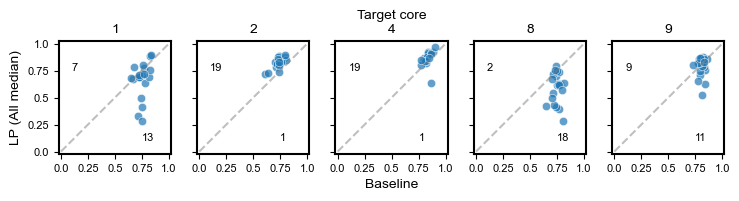

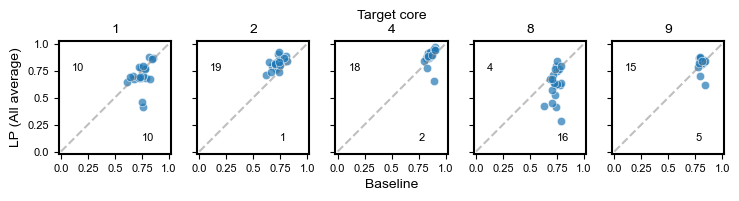

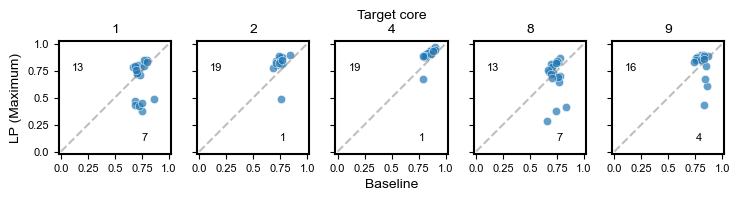

In [13]:
# median_scores = [np.zeros((2, 5)), np.zeros((2, 5)), np.zeros((2, 5))]
score_diff_list = [np.zeros((20,5)), np.zeros((20,5)), np.zeros((20,5)), np.zeros((20,5))] 

for a in range(4):
    df_to_plot = pd.DataFrame(all_vs_baseline_dict)
    fig, ax = plt.subplots(figsize=(7.5, 2), ncols=5, tight_layout=True, sharey=True)
    for i, t in enumerate(target_cores):
        sub_df = df_to_plot[(df_to_plot["Target core"]==t) & (df_to_plot["Aggregation"]==aggregations[a])]
        score_diffs = sub_df["LP AUPRC"].values - sub_df["Baseline AUPRC"].values
        score_diff_list[a][:, i] = score_diffs
        ax[i].annotate(len(np.where(score_diffs > 0)[0]), (0.1, 0.75), font="arial", fontsize=8)
        ax[i].annotate(len(np.where(score_diffs < 0)[0]), (0.75, 0.1), font="arial", fontsize=8)
        print()
        sns.scatterplot(data=sub_df, x="Baseline AUPRC", y="LP AUPRC", ax=ax[i], alpha=0.7)
        ax[i].set_aspect("equal")
        for axis in ["top", "bottom", "left", "right"]:
            ax[i].spines[axis].set_linewidth(1.5)
        ax[i].set_xlim(-0.02, 1.02)
        ax[i].set_ylim(-0.02, 1.02)
        ax[i].set_xticks(np.arange(0, 1.1, 0.25))
        ax[i].set_xticklabels([f"{round(x,2):02}" for x in np.arange(0, 1.1, 0.25)], fontsize=8,fontfamily="Arial")
        ax[i].set_yticks(np.arange(0, 1.1, 0.25))
        if i == 0 :
            ax[i].set_yticklabels([f"{round(x,2):02}" for x in np.arange(0, 1.1, 0.25)], fontsize=8,fontfamily="Arial")
            ax[i].set_ylabel(f"LP ({aggregations[a]})", fontdict={"fontsize": 10, "fontfamily": "Arial"})
        if i == 2 :
            ax[i].set_xlabel("Baseline", fontdict={"fontsize": 10, "fontfamily": "Arial"})
            ax[i].set_title(f"Target core\n{t+1}", fontdict={"fontsize": 10, "fontfamily": "Arial"})
        else :
            ax[i].set_title(f"{t+1}", fontdict={"fontsize": 10, "fontfamily": "Arial"})
            ax[i].set_xlabel("")

        ax[i].plot(np.arange(0, 1.01, 0.02), np.arange(0, 1.01, 0.02),ls="--", color="grey", alpha=0.5)
    # plt.savefig(f"../figures/SI/FigureSX_{aggregations[a]}.svg", format="svg", dpi=300)

In [14]:
per_core_auprc_benefit = [np.mean(x, axis=0) for x in score_diff_list]
all_auprc_benefit = [np.mean(x) for x in per_core_auprc_benefit]

In [15]:
per_core_auprc_benefit

[array([-0.00935006,  0.06246834,  0.03468609, -0.02092231,  0.02261524]),
 array([-0.08436933,  0.0910446 ,  0.0309094 , -0.1578656 , -0.02432132]),
 array([-0.03939051,  0.09512353,  0.02520327, -0.10681866,  0.00936369]),
 array([-0.05779796,  0.07230406,  0.05878291, -0.02447393,  0.00417494])]

In [16]:
all_auprc_benefit

[0.01789946135030123,
 -0.028920452559784777,
 -0.0033037347737130867,
 0.01059800337515791]